In [273]:
%pip install pingouin

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import ast
import statsmodels.formula.api as smf
import pingouin as pg

Note: you may need to restart the kernel to use updated packages.


### Process b3a_cov.dta

In [496]:
b3a_cov = pd.read_stata('adult_a/b3a_cov.dta')
b3a_cov

,hhid14_9,pid14,idivwr,resvis,rspndnt,panel,age,marstat,sex,dob_day,...,birth_cert_reas,hhid14,stemid,pid,pidlink,cp1,cp2,cp3,version,module
0,001060000,1.000,A35,1:Yes,1:Head of household,3:New,59.000,2:Married,1:Male,5.000,...,5:Didn't know it was required,0010600,00106,1.000,001060001,CF,2:Good,2:Good,1.300,B3A_COV
1,001060004,1.000,A34,1:Yes,2:Spouse of head,3:New,28.000,2:Married,3:Female,98:Don't Know,...,7:Cannot show if asked /misplaced birth certif...,0010651,00106,1.000,001060004,BD,3:Fair,3:Fair,1.300,B3A_COV
2,001060000,7.000,A33,1:Yes,2:Spouse of head,3:New,39.000,2:Married,3:Female,7.000,...,NaN,0010600,00106,7.000,001060007,BCD,1:Excellent,1:Excellent,1.300,B3A_COV
3,001060000,8.000,A33,1:Yes,3:Other HH member,3:New,16.000,1:Not yet married,3:Female,9.000,...,NaN,0010600,00106,8.000,001060008,EF,1:Excellent,1:Excellent,1.300,B3A_COV
4,001060004,2.000,A35,1:Yes,1:Head of household,3:New,30.000,2:Married,1:Male,4.000,...,5:Didn't know it was required,0010651,00106,2.000,001065102,BD,2:Good,2:Good,1.300,B3A_COV
5,001080003,1.000,A35,1:Yes,1:Head of household,3:New,36.000,2:Married,1:Male,13.000,...,5:Didn't know it was required,0010851,00108,1.000,001080003,BCF,2:Good,2:Good,1.300,B3A_COV
6,001080000,8.000,A31,1:Yes,1:Head of household,3:New,26.000,1:Not yet married,1:Male,10.000,...,NaN,0010800,00108,8.000,001080008,F,2:Good,2:Good,1.300,B3A_COV
7,001080003,2.000,A31,1:Yes,2:Spouse of head,3:New,40.000,2:Married,3:Female,3.000,...,7:Cannot show if asked /misplaced birth certif...,0010851,00108,2.000,001080012,EF,2:Good,2:Good,1.300,B3A_COV
8,001220000,1.000,A33,1:Yes,1:Head of household,1:Panel,55.000,2:Married,1:Male,17.000,...,5:Didn't know it was required,0012200,00122,1.000,001220001,BCDEF,1:Excellent,1:Excellent,1.300,B3A_COV
9,001220000,2.000,A35,1:Yes,2:Spouse of head,1:Panel,54.000,2:Married,3:Female,5.000,...,5:Didn't know it was required,0012200,00122,2.000,001220002,CF,2:Good,2:Good,1.300,B3A_COV


In [497]:
b3a_cov_clean = b3a_cov[['pidlink', 'marstat', 'age', 'sex']]
b3a_cov_clean

,pidlink,marstat,age,sex
0,001060001,2:Married,59.000,1:Male
1,001060004,2:Married,28.000,3:Female
2,001060007,2:Married,39.000,3:Female
3,001060008,1:Not yet married,16.000,3:Female
4,001065102,2:Married,30.000,1:Male
5,001080003,2:Married,36.000,1:Male
6,001080008,1:Not yet married,26.000,1:Male
7,001080012,2:Married,40.000,3:Female
8,001220001,2:Married,55.000,1:Male
9,001220002,2:Married,54.000,3:Female


# Wrong

In [498]:
#values_drop = ['1:Not yet married', '6:Cohabitate']
#b3a_cov_clean = b3a_cov_clean[~b3a_cov_clean['marstat'].isin(values_drop)]
#b3a_cov_clean #why clean not married?

## Explore the data of marriage
This is good to know the ratio of people who are already married and not yet married.

In [499]:
#Marital status explore
b3a_cov_clean.describe(include='all')
b3a_cov_clean['marstat'].value_counts()

marstat
2:Married            25800
1:Not yet married     7215
5:Widowed             2366
4:Divorced             819
3:Separated            178
6:Cohabitate             7
Name: count, dtype: int64

In [500]:
#categorizing married and never married
ever_mar=['2:Married', '5:Widowed', '4:Divorced', '3:Separated', '6:Cohabitate']
b3a_cov_clean['ever_married']=b3a_cov_clean['marstat'].isin(ever_mar).astype(int)
b3a_cov_clean['ever_married'].value_counts()

C:\Users\hp\AppData\Local\Temp\ipykernel_29388\3015497757.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b3a_cov_clean['ever_married']=b3a_cov_clean['marstat'].isin(ever_mar).astype(int)


ever_married
1    29170
0     7221
Name: count, dtype: int64

In [501]:
#categorizing male
male=['1:Male']
b3a_cov_clean['male']=b3a_cov_clean['sex'].isin(male).astype(int)
b3a_cov_clean['male'].value_counts()

C:\Users\hp\AppData\Local\Temp\ipykernel_29388\2384452185.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b3a_cov_clean['male']=b3a_cov_clean['sex'].isin(male).astype(int)


male
0    18831
1    17560
Name: count, dtype: int64

In [502]:
#exploring age
b3a_cov_clean['age'].unique()
(b3a_cov_clean['age'] == "998:Don't Know").sum()

4

In [503]:
b3a_cov_clean = b3a_cov_clean.dropna()
b3a_cov_clean

,pidlink,marstat,age,sex,ever_married,male
0,001060001,2:Married,59.000,1:Male,1,1
1,001060004,2:Married,28.000,3:Female,1,0
2,001060007,2:Married,39.000,3:Female,1,0
3,001060008,1:Not yet married,16.000,3:Female,0,0
4,001065102,2:Married,30.000,1:Male,1,1
5,001080003,2:Married,36.000,1:Male,1,1
6,001080008,1:Not yet married,26.000,1:Male,0,1
7,001080012,2:Married,40.000,3:Female,1,0
8,001220001,2:Married,55.000,1:Male,1,1
9,001220002,2:Married,54.000,3:Female,1,0


In [504]:
b3a_cov_clean.to_csv('clean_data/b3a_cov_clean.csv', index=False)

# Start Over Again?

In [505]:
b3a_cov_clean['male'].value_counts()

male
0    18825
1    17560
Name: count, dtype: int64

In [506]:
b3a_cov_clean['marstat'].value_counts()

marstat
2:Married            25800
1:Not yet married     7215
5:Widowed             2366
4:Divorced             819
3:Separated            178
6:Cohabitate             7
Name: count, dtype: int64

In [507]:
b3a_cov_clean = pd.read_csv('clean_data/b3a_cov_clean.csv')
b3a_cov_clean

,pidlink,marstat,age,sex,ever_married,male
0,1060001,2:Married,59.0,1:Male,1,1
1,1060004,2:Married,28.0,3:Female,1,0
2,1060007,2:Married,39.0,3:Female,1,0
3,1060008,1:Not yet married,16.0,3:Female,0,0
4,1065102,2:Married,30.0,1:Male,1,1
5,1080003,2:Married,36.0,1:Male,1,1
6,1080008,1:Not yet married,26.0,1:Male,0,1
7,1080012,2:Married,40.0,3:Female,1,0
8,1220001,2:Married,55.0,1:Male,1,1
9,1220002,2:Married,54.0,3:Female,1,0


In [508]:
pd.set_option('display.min_rows', None)

In [509]:
b3a_cov_clean['age'].value_counts()

age
32.0              1111
31.0              1039
33.0              1023
30.0              1007
35.0               996
34.0               995
15.0               931
29.0               924
27.0               901
36.0               884
28.0               882
37.0               871
25.0               861
39.0               829
26.0               813
24.0               804
38.0               799
16.0               790
23.0               763
19.0               756
22.0               755
17.0               754
42.0               745
40.0               722
18.0               721
20.0               695
21.0               693
44.0               684
41.0               683
43.0               629
                  ... 
75.0               108
81.0               100
79.0                86
77.0                84
78.0                65
82.0                54
86.0                50
84.0                50
80.0                44
87.0                37
83.0                33
85.0                26
91.0   

In [510]:
b3a_cov_clean = b3a_cov_clean[b3a_cov_clean['age'] != "998:Don't Know"]
b3a_cov_clean

,pidlink,marstat,age,sex,ever_married,male
0,1060001,2:Married,59.0,1:Male,1,1
1,1060004,2:Married,28.0,3:Female,1,0
2,1060007,2:Married,39.0,3:Female,1,0
3,1060008,1:Not yet married,16.0,3:Female,0,0
4,1065102,2:Married,30.0,1:Male,1,1
5,1080003,2:Married,36.0,1:Male,1,1
6,1080008,1:Not yet married,26.0,1:Male,0,1
7,1080012,2:Married,40.0,3:Female,1,0
8,1220001,2:Married,55.0,1:Male,1,1
9,1220002,2:Married,54.0,3:Female,1,0


In [511]:
b3a_cov_clean['age'] = b3a_cov_clean['age'].astype(float).astype(int) #convert age to numeric as string contains .0, so need to first convert to float then to int
b3a_cov_clean

C:\Users\hp\AppData\Local\Temp\ipykernel_29388\2577330344.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b3a_cov_clean['age'] = b3a_cov_clean['age'].astype(float).astype(int) #convert age to numeric as string contains .0, so need to first convert to float then to int


,pidlink,marstat,age,sex,ever_married,male
0,1060001,2:Married,59,1:Male,1,1
1,1060004,2:Married,28,3:Female,1,0
2,1060007,2:Married,39,3:Female,1,0
3,1060008,1:Not yet married,16,3:Female,0,0
4,1065102,2:Married,30,1:Male,1,1
5,1080003,2:Married,36,1:Male,1,1
6,1080008,1:Not yet married,26,1:Male,0,1
7,1080012,2:Married,40,3:Female,1,0
8,1220001,2:Married,55,1:Male,1,1
9,1220002,2:Married,54,3:Female,1,0


In [512]:
b3a_cov_clean['age'].describe()

count   36381.000
mean       38.391
std        16.029
min        14.000
25%        26.000
50%        35.000
75%        48.000
max       110.000
Name: age, dtype: float64

In [513]:
b3a_cov_clean['sex'].value_counts()

sex
3:Female    18823
1:Male      17558
Name: count, dtype: int64

In [514]:
b3a_cov_clean['sex'].value_counts(normalize=True)

sex
3:Female   0.517
1:Male     0.483
Name: proportion, dtype: float64

### Process b3a_dl1.dta

In [515]:
b3a_dl1 = pd.read_stata('adult_a/b3a_dl1.dta')
b3a_dl1

,hhid14_9,pid14,dl01a,dl01f,dl01g,dl01h,dl01e,dl02,dl02a,dl03,...,dl16xd,dl30,dl40,dl41,dl42,dl43,hhid14,pidlink,version,module
0,001060000,1.000,N,M,M,M,13:Nias,1:Yes,1:Yes,1:Yes,...,NaN,NaN,,NaN,NaN,,0010600,001060001,1.300,B3A_DL1
1,001060004,1.000,N,M,M,M,96:None,1:Yes,1:Yes,1:Yes,...,2:New respondent,3:No,,NaN,NaN,,0010651,001060004,1.300,B3A_DL1
2,001060000,7.000,N,M,M,M,13:Nias,3:No,3:No,3:No,...,2:New respondent,3:No,,NaN,NaN,,0010600,001060007,1.300,B3A_DL1
3,001060000,8.000,WN,M,M,M,13:Nias,1:Yes,1:Yes,1:Yes,...,2:New respondent,1:Yes,A,3:No,3:No,,0010600,001060008,1.300,B3A_DL1
4,001060004,2.000,N,M,M,M,13:Nias,1:Yes,1:Yes,1:Yes,...,2:New respondent,3:No,,NaN,NaN,,0010651,001065102,1.300,B3A_DL1
5,001080003,1.000,N,M,M,M,13:Nias,3:No,3:No,3:No,...,2:New respondent,3:No,,NaN,NaN,,0010851,001080003,1.300,B3A_DL1
6,001080000,8.000,N,M,M,M,13:Nias,1:Yes,1:Yes,1:Yes,...,2:New respondent,3:No,,NaN,NaN,,0010800,001080008,1.300,B3A_DL1
7,001080003,2.000,N,M,M,M,13:Nias,3:No,3:No,3:No,...,NaN,NaN,,NaN,NaN,,0010851,001080012,1.300,B3A_DL1
8,001220000,1.000,N,M,M,M,13:Nias,1:Yes,1:Yes,3:No,...,NaN,NaN,,NaN,NaN,,0012200,001220001,1.300,B3A_DL1
9,001220000,2.000,N,M,M,M,13:Nias,1:Yes,1:Yes,1:Yes,...,NaN,NaN,,NaN,NaN,,0012200,001220002,1.300,B3A_DL1


In [516]:
b3a_dl1_clean = b3a_dl1[['pidlink', 'dl01f', 'dl06']]
b3a_dl1_clean

,pidlink,dl01f,dl06
0,001060001,M,2:Elementary school
1,001060004,M,2:Elementary school
2,001060007,M,2:Elementary school
3,001060008,M,3:Junior high general
4,001065102,M,3:Junior high general
5,001080003,M,2:Elementary school
6,001080008,M,2:Elementary school
7,001080012,M,NaN
8,001220001,M,2:Elementary school
9,001220002,M,2:Elementary school


In [517]:
b3a_dl1_clean = b3a_dl1_clean.dropna()
b3a_dl1_clean

,pidlink,dl01f,dl06
0,001060001,M,2:Elementary school
1,001060004,M,2:Elementary school
2,001060007,M,2:Elementary school
3,001060008,M,3:Junior high general
4,001065102,M,3:Junior high general
5,001080003,M,2:Elementary school
6,001080008,M,2:Elementary school
8,001220001,M,2:Elementary school
9,001220002,M,2:Elementary school
10,001220003,M,61:University S1


In [518]:
b3a_dl1_clean.to_csv('clean_data/b3a_dl1_clean.csv', index=False)

In [519]:
b3a_dl1_clean = pd.read_csv('clean_data/b3a_dl1_clean.csv')
b3a_dl1_clean

,pidlink,dl01f,dl06
0,1060001,M,2:Elementary school
1,1060004,M,2:Elementary school
2,1060007,M,2:Elementary school
3,1060008,M,3:Junior high general
4,1065102,M,3:Junior high general
5,1080003,M,2:Elementary school
6,1080008,M,2:Elementary school
7,1220001,M,2:Elementary school
8,1220002,M,2:Elementary school
9,1220003,M,61:University S1


In [520]:
b3a_dl1_clean['dl01f'].value_counts()

dl01f
A        13226
B         3836
I         1677
D         1351
H         1321
C         1318
Q         1130
E         1082
J         1039
C1         987
G          735
K          630
L          450
S          236
O          216
N          198
V          176
P          149
F          141
M          110
D1         103
T           94
B1          26
E L         20
A G         17
A B         15
U           14
E1          13
A Q         12
R           11
         ...  
C V          1
H S          1
A A1V        1
H O          1
H Q          1
A O          1
E J          1
A R          1
B I          1
A D1         1
A B H        1
R C1         1
S V          1
S C1         1
G C1         1
F I          1
F M          1
N V          1
G I          1
N C1         1
B Q S        1
Z            1
F1           1
D Q          1
F Q          1
J Q          1
B J          1
B E1         1
N Q          1
B L          1
Name: count, Length: 84, dtype: int64

In [521]:
b3a_dl1_clean['dl06'].value_counts()

dl06
2:Elementary school                                    9896
5:Senior high general                                  5341
3:Junior high general                                  5124
6:Senior high vocational                               4546
61:University S1                                       3192
60:College (D1,D2,D3)                                  1226
73:Islamic Junior/High School (Madrasah Tsanawiyah)    1100
74:Islamic Senior/High School (Madrasah Tsanawiyah)     909
72:Islamic Elementary School (Madrasah Ibtidaiyah)      403
15:Adult education C                                    240
4:Junior high vocational                                206
62:University S2                                        202
12:Adult education B                                    108
14:Islamic School (pesantren)                            78
13:Open university                                       28
11:Adult education A                                     22
95:Other                           

In [522]:
education_mapping = {
    '2:Elementary school': 6,
    '5:Senior high general': 12, # 6 (SD) + 3 (SMP) + 3 (SMA)
    '3:Junior high general': 9,  # 6 (SD) + 3 (SMP)
    '6:Senior high vocational': 13,
    '61:University S1': 16, # 12 (SMA) + 4 (S1)
    '60:College (D1,D2,D3)': 15, # 12 (SMA) + 2 (D2, example)
    '73:Islamic Junior/High School (Madrasah Tsanawiyah)': 9,
    '74:Islamic Senior/High School (Madrasah Tsanawiyah)': 12,
    '72:Islamic Elementary School (Madrasah Ibtidaiyah)': 6,
    '15:Adult education C': 9,
    '4:Junior high vocational': 9,
    '62:University S2': 18,
    '12:Adult education B': 6,
    '14:Islamic School (pesantren)': np.nan, # Varies, or can be mapped to others
    '13:Open university': 16,
    '11:Adult education A': 3,
    '95:Other': np.nan,
    '17:School for Disabled': np.nan,
    '63:University S3': 22,
    '98:Don\'t Know': np.nan,
    '99:MISSING': np.nan,
    '90:Kindergarten': 0
}

In [523]:
b3a_dl1_clean['dl06'] = b3a_dl1_clean['dl06'].map(education_mapping)
b3a_dl1_clean

,pidlink,dl01f,dl06
0,1060001,M,6.000
1,1060004,M,6.000
2,1060007,M,6.000
3,1060008,M,9.000
4,1065102,M,9.000
5,1080003,M,6.000
6,1080008,M,6.000
7,1220001,M,6.000
8,1220002,M,6.000
9,1220003,M,16.000


In [524]:
b3a_dl1_clean = b3a_dl1_clean.dropna(subset=['dl06'])
b3a_dl1_clean['educ']=b3a_dl1_clean['dl06']
b3a_dl1_clean

C:\Users\hp\AppData\Local\Temp\ipykernel_29388\461434664.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b3a_dl1_clean['educ']=b3a_dl1_clean['dl06']


,pidlink,dl01f,dl06,educ
0,1060001,M,6.000,6.000
1,1060004,M,6.000,6.000
2,1060007,M,6.000,6.000
3,1060008,M,9.000,9.000
4,1065102,M,9.000,9.000
5,1080003,M,6.000,6.000
6,1080008,M,6.000,6.000
7,1220001,M,6.000,6.000
8,1220002,M,6.000,6.000
9,1220003,M,16.000,16.000


In [525]:
b3a_dl1_clean.to_csv('clean_data/b3a_dl1_clean.csv', index=False)

### Process b3a_tk2.dta

In [526]:
b3a_tk2 = pd.read_stata('adult_a/b3a_tk2.dta')
b3a_tk2

,hhid14_9,pid14,tkp18ax,tk18abx,tkp19ax,tkp19aa,tkp20ax,tk20aax,tk20aa,tk20ab,...,tk25b1,tk25b2,tk25b2b,tk23bx,tk23b2mx,tk23b2yx,version,module,tk26b1,tk26b3
0,001060004,1.000,NaN,W,NaN,NaN,NaN,1:Given,2.000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.300,B3A_TK2,NaN,NaN
1,001060000,7.000,NaN,W,NaN,NaN,NaN,1:Given,3.000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.300,B3A_TK2,NaN,NaN
2,001060000,8.000,NaN,W,NaN,NaN,NaN,1:Given,2.000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.300,B3A_TK2,NaN,NaN
3,001060004,2.000,NaN,W,NaN,NaN,NaN,1:Given,2.000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.300,B3A_TK2,NaN,NaN
4,001080003,1.000,NaN,W,NaN,NaN,NaN,1:Given,2.000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.300,B3A_TK2,NaN,NaN
5,001080000,8.000,NaN,B,NaN,NaN,NaN,1:Given,1.000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.300,B3A_TK2,NaN,NaN
6,001080003,2.000,NaN,W,NaN,NaN,NaN,1:Given,2.000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.300,B3A_TK2,NaN,NaN
7,001220000,2.000,NaN,W,NaN,NaN,NaN,1:Given,2.000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.300,B3A_TK2,NaN,NaN
8,001224100,1.000,NaN,W,NaN,NaN,NaN,1:Given,7.000,NaN,...,NaN,NaN,NaN,1.000,1.000,1.000,1.300,B3A_TK2,500000.000,5000000.000
9,001220000,6.000,NaN,W,NaN,NaN,NaN,1:Given,7.000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.300,B3A_TK2,NaN,NaN


In [527]:
b3a_tk2_clean = b3a_tk2[['pidlink', 'tk25a1', 'tk25a2']]
b3a_tk2_clean

,pidlink,tk25a1,tk25a2
0,001060004,NaN,NaN
1,001060007,NaN,NaN
2,001060008,NaN,NaN
3,001065102,NaN,NaN
4,001080003,NaN,NaN
5,001080008,NaN,NaN
6,001080012,NaN,NaN
7,001220002,NaN,NaN
8,001220003,0.000,3500000.000
9,001220006,2000000.000,8000000.000


In [528]:
b3a_tk2_clean = b3a_tk2_clean.dropna()
b3a_tk2_clean

,pidlink,tk25a1,tk25a2
8,001220003,0.000,3500000.000
9,001220006,2000000.000,8000000.000
10,001220008,700000.000,2050000.000
15,001240007,200000.000,3600000.000
19,001240016,240000.000,240000.000
21,001240024,1700000.000,6800000.000
24,001245201,800000.000,1200000.000
28,001290004,400000.000,3000000.000
35,002010005,1400000.000,17300000.000
36,002010006,1500000.000,4700000.000


In [529]:
b3a_tk2_clean.to_csv('clean_data/b3a_tk2_clean.csv', index=False)

In [530]:
b3a_tk2_clean = pd.read_csv('clean_data/b3a_tk2_clean.csv')
b3a_tk2_clean

,pidlink,tk25a1,tk25a2
0,1220003,0.000,3500000.000
1,1220006,2000000.000,8000000.000
2,1220008,700000.000,2050000.000
3,1240007,200000.000,3600000.000
4,1240016,240000.000,240000.000
5,1240024,1700000.000,6800000.000
6,1245201,800000.000,1200000.000
7,1290004,400000.000,3000000.000
8,2010005,1400000.000,17300000.000
9,2010006,1500000.000,4700000.000


In [531]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [532]:
b3a_tk2_clean[['tk25a1','tk25a2']].describe()

,tk25a1,tk25a2
count,12398.000,12398.000
mean,1931010.727,20692403.430
std,12903603.042,32885408.705
min,0.000,0.000
25%,550000.000,4000000.000
50%,1250000.000,12000000.000
75%,2400000.000,27000000.000
max,999999997.000,999999997.000


In [533]:
bins = [
    0,         # < 500,000
    500000,    # 500,000 - 1,000,000
    1000000,   # 1,000,000 - 2,000,000
    2000000,   # 2,000,000 - 4,000,000
    4000000,
    10000000,
    20000000,
    np.inf     # > 4,000,000
]

labels = [
    '< 500,000',
    '500,000 - 1,000,000',
    '1,000,000 - 2,000,000',
    '2,000,000 - 4,000,000',
    '4,000,000 - 10,000,000',
    '10,000,000 - 20,000,000',
    '> 20,000,000'
]

df_income = pd.cut(b3a_tk2_clean['tk25a1'], bins=bins, labels=labels, right=False)

In [534]:
income_counts = df_income.value_counts().sort_index()
income_counts

tk25a1
< 500,000                  2572
500,000 - 1,000,000        2132
1,000,000 - 2,000,000      3485
2,000,000 - 4,000,000      3116
4,000,000 - 10,000,000      977
10,000,000 - 20,000,000      84
> 20,000,000                 32
Name: count, dtype: int64

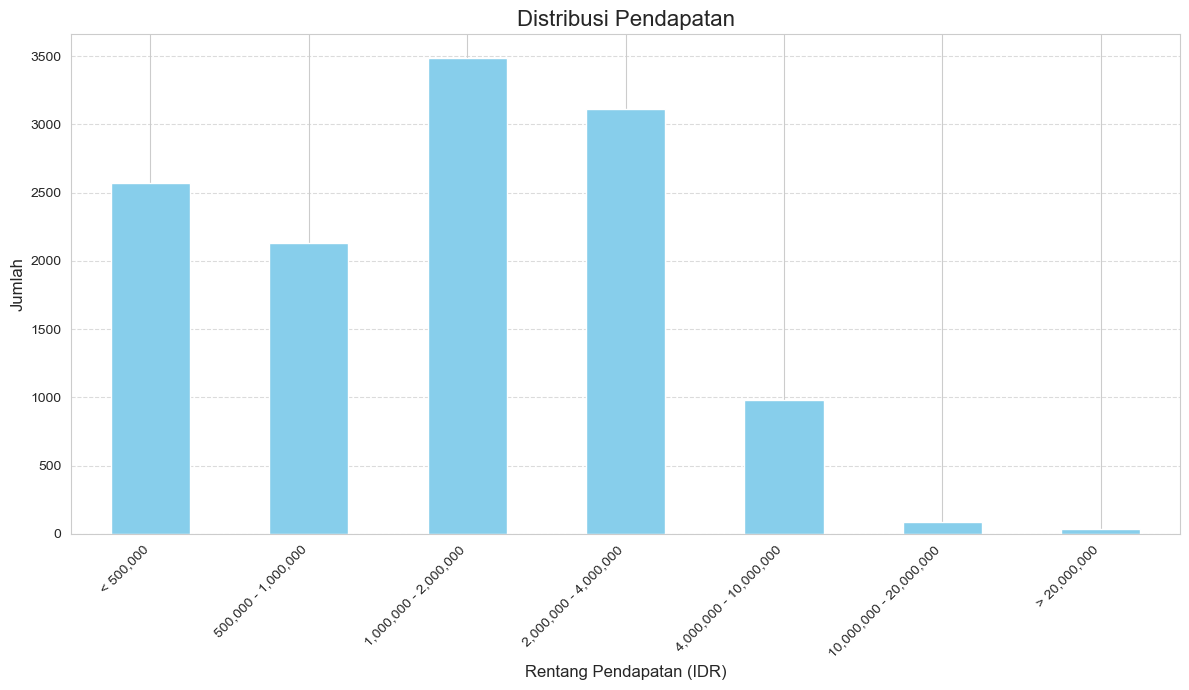

In [535]:
# Create a bar chart
plt.figure(figsize=(12, 7))
income_counts.plot(kind='bar', color='skyblue')

# Set labels and title
plt.title('Distribusi Pendapatan', fontsize=16)
plt.xlabel('Rentang Pendapatan (IDR)', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add a grid for easier reading
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout to make sure labels are not cut off
plt.tight_layout()

# Save the plot
plt.savefig('income_distribution_bar_chart.png')

### Process

In [536]:
b3a_kw1 = pd.read_stata('adult_a/b3a_kw1.dta')
b3a_kw1

,hhid14_9,pid14,kw300a,kw00ba,kw00bc,kw00c,kw00d,kw01a,kw301,kw02a1,...,kw27a,kw27b,hhid14,pidlink,kw02m,kw12b,kw13b,kw14,version,module
0,001060000,1.000,3:No,NaN,NaN,NaN,NaN,5:Married formal according to adat law,3:No,1:Yes,...,NaN,NaN,0010600,001060001,NaN,NaN,2000000.000,200000.000,1.300,B3A_KW1
1,001060004,1.000,3:No,NaN,NaN,NaN,NaN,5:Married formal according to adat law,1:Yes,NaN,...,NaN,NaN,0010651,001060004,NaN,NaN,NaN,NaN,1.300,B3A_KW1
2,001060000,7.000,3:No,NaN,NaN,NaN,NaN,3:Married formal (KUA or civil registration),1:Yes,NaN,...,NaN,NaN,0010600,001060007,NaN,NaN,NaN,NaN,1.300,B3A_KW1
3,001060000,8.000,3:No,NaN,NaN,NaN,NaN,1:Never married,NaN,NaN,...,NaN,NaN,0010600,001060008,NaN,NaN,NaN,NaN,1.300,B3A_KW1
4,001060004,2.000,3:No,NaN,NaN,NaN,NaN,3:Married formal (KUA or civil registration),3:No,1:Yes,...,NaN,NaN,0010651,001065102,NaN,NaN,NaN,NaN,1.300,B3A_KW1
5,001080003,1.000,3:No,NaN,NaN,NaN,NaN,3:Married formal (KUA or civil registration),3:No,1:Yes,...,NaN,NaN,0010851,001080003,NaN,NaN,250000.000,0.000,1.300,B3A_KW1
6,001080000,8.000,3:No,NaN,NaN,NaN,NaN,1:Never married,NaN,NaN,...,NaN,NaN,0010800,001080008,NaN,NaN,NaN,NaN,1.300,B3A_KW1
7,001080003,2.000,3:No,NaN,NaN,NaN,NaN,4:Married formal according to religious law,1:Yes,NaN,...,NaN,NaN,0010851,001080012,NaN,NaN,NaN,NaN,1.300,B3A_KW1
8,001220000,1.000,1:Yes,4.000,2.000,1:Yes,3:No,NaN,NaN,1:Yes,...,NaN,NaN,0012200,001220001,NaN,NaN,NaN,NaN,1.300,B3A_KW1
9,001220000,2.000,3:No,NaN,NaN,NaN,NaN,3:Married formal (KUA or civil registration),1:Yes,NaN,...,NaN,NaN,0012200,001220002,NaN,NaN,NaN,NaN,1.300,B3A_KW1


In [537]:
b3a_kw1['kw04'].value_counts()

kw04
3:Self                               4130
1:Parents                             203
4:Other family member from parent      61
5:Others                               35
9:MISSING                               2
Name: count, dtype: int64

In [538]:
b3a_kw1_clean = b3a_kw1[['pidlink', 'kw03', 'kw04']]
b3a_kw1_clean

,pidlink,kw03,kw04
0,001060001,2.000,3:Self
1,001060004,NaN,NaN
2,001060007,NaN,NaN
3,001060008,NaN,NaN
4,001065102,1.000,1:Parents
5,001080003,1.000,3:Self
6,001080008,NaN,NaN
7,001080012,NaN,NaN
8,001220001,NaN,NaN
9,001220002,NaN,NaN


In [539]:
b3a_kw1_clean = b3a_kw1_clean.dropna()
b3a_kw1_clean

,pidlink,kw03,kw04
0,001060001,2.000,3:Self
4,001065102,1.000,1:Parents
5,001080003,1.000,3:Self
16,001240002,1.000,1:Parents
17,001240003,1.000,1:Parents
18,001240004,1.000,3:Self
28,001245101,2.000,3:Self
29,001245201,1.000,4:Other family member from parent
34,001290004,1.000,3:Self
35,001290005,1.000,3:Self


In [540]:
b3a_kw1_clean['kw04'].value_counts()

kw04
3:Self                               4130
1:Parents                             203
4:Other family member from parent      61
5:Others                               35
9:MISSING                               2
Name: count, dtype: int64

In [541]:
values_drop = ['9:MISSING']
b3a_kw1_clean = b3a_kw1_clean[~b3a_kw1_clean['kw04'].isin(values_drop)]
b3a_kw1_clean

,pidlink,kw03,kw04
0,001060001,2.000,3:Self
4,001065102,1.000,1:Parents
5,001080003,1.000,3:Self
16,001240002,1.000,1:Parents
17,001240003,1.000,1:Parents
18,001240004,1.000,3:Self
28,001245101,2.000,3:Self
29,001245201,1.000,4:Other family member from parent
34,001290004,1.000,3:Self
35,001290005,1.000,3:Self


In [542]:
b3a_kw1_clean['kw03'].value_counts()

kw03
1.0              3763
2.0               521
3.0                96
4.0                24
5.0                10
6.0                 7
8.0                 4
9.0                 2
11.0                2
10.0                0
98:Don't Know       0
99:MISSING          0
Name: count, dtype: int64

In [543]:
b3a_kw1_clean

,pidlink,kw03,kw04
0,001060001,2.000,3:Self
4,001065102,1.000,1:Parents
5,001080003,1.000,3:Self
16,001240002,1.000,1:Parents
17,001240003,1.000,1:Parents
18,001240004,1.000,3:Self
28,001245101,2.000,3:Self
29,001245201,1.000,4:Other family member from parent
34,001290004,1.000,3:Self
35,001290005,1.000,3:Self


In [544]:
b3a_kw1_clean.to_csv('clean_data/b3a_kw1_clean.csv', index=False)

### Process b4

In [545]:
b4_kw2 = pd.read_stata('female/b4_kw2.dta')
b4_kw2

,hhid14_9,pid14,kw00a,kw00ba,kw00bc,kw00c,kw00d,kw03a,kw03,kw02a1,...,kw24a,kw24b,kw25,kw26x,kw26,kw27x,kw27a,kw27b,version,module
0,001060004,1.000,3:No => KW03a,NaN,NaN,NaN,NaN,5:Married formal according to adat law,1.000,1:Yes,...,1:Yes,NaN,1:Yes,95:Up to God,NaN,95:Up to God,NaN,NaN,1.300,B4_KW2
1,001060000,7.000,3:No => KW03a,NaN,NaN,NaN,NaN,3:Married formal (KUA or civil registration),1.000,1:Yes,...,1:Yes,NaN,1:Yes,95:Up to God,NaN,95:Up to God,NaN,NaN,1.300,B4_KW2
2,001080003,2.000,3:No => KW03a,NaN,NaN,NaN,NaN,4:Married formal according to religious law,1.000,3:No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.300,B4_KW2
3,001220000,2.000,1:Yes,4.000,1.000,1:Yes,3:No => KW02A1,NaN,NaN,1:Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.300,B4_KW2
4,001224100,2.000,3:No => KW03a,NaN,NaN,NaN,NaN,3:Married formal (KUA or civil registration),1.000,1:Yes,...,1:Yes,NaN,3:No,NaN,NaN,NaN,NaN,NaN,1.300,B4_KW2
5,001240005,2.000,3:No => KW03a,NaN,NaN,NaN,NaN,3:Married formal (KUA or civil registration),1.000,1:Yes,...,1:Yes,NaN,1:Yes,1:Given,3.000,1:Given,1.000,2.000,1.300,B4_KW2
6,001240009,2.000,3:No => KW03a,NaN,NaN,NaN,NaN,3:Married formal (KUA or civil registration),1.000,1:Yes,...,1:Yes,NaN,1:Yes,1:Given,3.000,1:Given,2.000,1.000,1.300,B4_KW2
7,001240000,25.000,3:No => KW03a,NaN,NaN,NaN,NaN,3:Married formal (KUA or civil registration),1.000,3:No,...,1:Yes,NaN,3:No,NaN,NaN,NaN,NaN,NaN,1.300,B4_KW2
8,001250000,8.000,1:Yes,3.000,3.000,1:Yes,3:No => KW02A1,NaN,NaN,1:Yes,...,1:Yes,NaN,1:Yes,1:Given,2.000,1:Given,1.000,1.000,1.300,B4_KW2
9,001290003,2.000,3:No => KW03a,NaN,NaN,NaN,NaN,3:Married formal (KUA or civil registration),1.000,1:Yes,...,1:Yes,NaN,3:No,NaN,NaN,NaN,NaN,NaN,1.300,B4_KW2


In [546]:
b4_kw2_clean = b4_kw2[['pidlink', 'kw03', 'kw04']]
b4_kw2_clean

,pidlink,kw03,kw04
0,001060004,1.000,1:Parent
1,001060007,1.000,3:Self
2,001080012,1.000,3:Self
3,001220002,NaN,NaN
4,001220011,1.000,1:Parent
5,001240005,1.000,1:Parent
6,001240009,1.000,1:Parent
7,001240025,1.000,1:Parent
8,001250008,NaN,NaN
9,001290003,1.000,3:Self


In [547]:
b4_kw2_clean['kw04'].value_counts()

kw04
3:Self      4114
1:Parent     273
4:Family      84
95:Other      32
Name: count, dtype: int64

In [548]:
b4_kw2_clean.to_csv('clean_data/b4_kw2_clean.csv', index=False)

### Process all

In [549]:
cov = pd.read_csv('clean_data/b3a_cov_clean.csv')
cov

,pidlink,marstat,age,sex,ever_married,male
0,1060001,2:Married,59.0,1:Male,1,1
1,1060004,2:Married,28.0,3:Female,1,0
2,1060007,2:Married,39.0,3:Female,1,0
3,1060008,1:Not yet married,16.0,3:Female,0,0
4,1065102,2:Married,30.0,1:Male,1,1
5,1080003,2:Married,36.0,1:Male,1,1
6,1080008,1:Not yet married,26.0,1:Male,0,1
7,1080012,2:Married,40.0,3:Female,1,0
8,1220001,2:Married,55.0,1:Male,1,1
9,1220002,2:Married,54.0,3:Female,1,0


In [550]:
dl1 = pd.read_csv('clean_data/b3a_dl1_clean.csv')
dl1

,pidlink,dl01f,dl06,educ
0,1060001,M,6.000,6.000
1,1060004,M,6.000,6.000
2,1060007,M,6.000,6.000
3,1060008,M,9.000,9.000
4,1065102,M,9.000,9.000
5,1080003,M,6.000,6.000
6,1080008,M,6.000,6.000
7,1220001,M,6.000,6.000
8,1220002,M,6.000,6.000
9,1220003,M,16.000,16.000


In [551]:
kw1 = pd.read_csv('clean_data/b3a_kw1_clean.csv')
kw1 = kw1.drop(columns=['kw04'])
kw1

,pidlink,kw03
0,1060001,2.000
1,1065102,1.000
2,1080003,1.000
3,1240002,1.000
4,1240003,1.000
5,1240004,1.000
6,1245101,2.000
7,1245201,1.000
8,1290004,1.000
9,1290005,1.000


In [552]:
tk2 = pd.read_csv('clean_data/b3a_tk2_clean.csv')
tk2

,pidlink,tk25a1,tk25a2
0,1220003,0.000,3500000.000
1,1220006,2000000.000,8000000.000
2,1220008,700000.000,2050000.000
3,1240007,200000.000,3600000.000
4,1240016,240000.000,240000.000
5,1240024,1700000.000,6800000.000
6,1245201,800000.000,1200000.000
7,1290004,400000.000,3000000.000
8,2010005,1400000.000,17300000.000
9,2010006,1500000.000,4700000.000


In [553]:
kw2 = pd.read_csv('clean_data/b4_kw2_clean.csv')
kw2 = kw2.drop(columns=['kw04'])
kw2

,pidlink,kw03
0,1060004,1.000
1,1060007,1.000
2,1080012,1.000
3,1220002,NaN
4,1220011,1.000
5,1240005,1.000
6,1240009,1.000
7,1240025,1.000
8,1250008,NaN
9,1290003,1.000


In [554]:
df_merged = pd.merge(cov, kw1, how='left', on='pidlink')
df_merged = pd.merge(df_merged, kw2, how='left', on='pidlink')
df_merged

,pidlink,marstat,age,sex,ever_married,male,kw03_x,kw03_y
0,1060001,2:Married,59.0,1:Male,1,1,2.000,NaN
1,1060004,2:Married,28.0,3:Female,1,0,NaN,1.000
2,1060007,2:Married,39.0,3:Female,1,0,NaN,1.000
3,1060008,1:Not yet married,16.0,3:Female,0,0,NaN,NaN
4,1065102,2:Married,30.0,1:Male,1,1,1.000,NaN
5,1080003,2:Married,36.0,1:Male,1,1,1.000,NaN
6,1080008,1:Not yet married,26.0,1:Male,0,1,NaN,NaN
7,1080012,2:Married,40.0,3:Female,1,0,NaN,1.000
8,1220001,2:Married,55.0,1:Male,1,1,NaN,NaN
9,1220002,2:Married,54.0,3:Female,1,0,NaN,NaN


In [555]:
# Create a new 'kw03' column by combining 'kw03_x' and 'kw03_y'
df_merged['kw03'] = df_merged['kw03_x'].fillna(df_merged['kw03_y'])

# Create a new 'kw04' column by combining 'kw04_x' and 'kw04_y'
# df_merged['kw04'] = df_merged['kw04_x'].fillna(df_merged['kw04_y'])

# Drop the original columns
df_merged = df_merged.drop(columns=['kw03_x', 'kw03_y'])
df_merged

,pidlink,marstat,age,sex,ever_married,male,kw03
0,1060001,2:Married,59.0,1:Male,1,1,2.000
1,1060004,2:Married,28.0,3:Female,1,0,1.000
2,1060007,2:Married,39.0,3:Female,1,0,1.000
3,1060008,1:Not yet married,16.0,3:Female,0,0,NaN
4,1065102,2:Married,30.0,1:Male,1,1,1.000
5,1080003,2:Married,36.0,1:Male,1,1,1.000
6,1080008,1:Not yet married,26.0,1:Male,0,1,NaN
7,1080012,2:Married,40.0,3:Female,1,0,1.000
8,1220001,2:Married,55.0,1:Male,1,1,NaN
9,1220002,2:Married,54.0,3:Female,1,0,NaN


In [556]:
df_merged = df_merged.dropna()
df_merged

,pidlink,marstat,age,sex,ever_married,male,kw03
0,1060001,2:Married,59.0,1:Male,1,1,2.000
1,1060004,2:Married,28.0,3:Female,1,0,1.000
2,1060007,2:Married,39.0,3:Female,1,0,1.000
4,1065102,2:Married,30.0,1:Male,1,1,1.000
5,1080003,2:Married,36.0,1:Male,1,1,1.000
7,1080012,2:Married,40.0,3:Female,1,0,1.000
14,1220011,2:Married,32.0,3:Female,1,0,1.000
16,1240002,5:Widowed,62.0,3:Female,1,0,1.000
17,1240003,5:Widowed,40.0,1:Male,1,1,1.000
18,1240004,2:Married,35.0,1:Male,1,1,1.000


In [557]:
df_merged['sex'].value_counts()

sex
3:Female    5332
1:Male      4155
Name: count, dtype: int64

In [558]:
df_merged = pd.merge(cov, dl1, how='inner', on='pidlink')
df_merged = pd.merge(df_merged, tk2, how='inner', on='pidlink')
df_merged

,pidlink,marstat,age,sex,ever_married,male,dl01f,dl06,educ,tk25a1,tk25a2
0,1220003,2:Married,34.0,1:Male,1,1,M,16.000,16.000,0.000,3500000.000
1,1220006,1:Not yet married,28.0,1:Male,0,1,M,16.000,16.000,2000000.000,8000000.000
2,1220008,1:Not yet married,24.0,1:Male,0,1,M,16.000,16.000,700000.000,2050000.000
3,1240007,1:Not yet married,30.0,3:Female,0,0,M,16.000,16.000,200000.000,3600000.000
4,1240016,1:Not yet married,17.0,1:Male,0,1,M,13.000,13.000,240000.000,240000.000
5,1240024,1:Not yet married,25.0,3:Female,0,0,D,16.000,16.000,1700000.000,6800000.000
6,1245201,2:Married,30.0,1:Male,1,1,M,9.000,9.000,800000.000,1200000.000
7,1290004,2:Married,29.0,1:Male,1,1,M,6.000,6.000,400000.000,3000000.000
8,2010005,1:Not yet married,26.0,1:Male,0,1,M,15.000,15.000,1400000.000,17300000.000
9,2010006,2:Married,24.0,3:Female,1,0,M,6.000,6.000,1500000.000,4700000.000


In [559]:
df_merged['sex'].value_counts()

sex
1:Male      7736
3:Female    4396
Name: count, dtype: int64

In [560]:
df_merged['marstat'].value_counts()

marstat
2:Married            8986
1:Not yet married    2506
4:Divorced            287
5:Widowed             283
3:Separated            67
6:Cohabitate            3
Name: count, dtype: int64

In [561]:
df_merged['dl01f'].value_counts()

dl01f
A        5201
B        1508
I         616
C         570
Q         488
H         470
D         395
E         307
J         302
C1        283
G         258
L         185
K         180
S          90
O          74
N          72
V          65
F          54
P          51
D1         42
M          36
T          34
E L        13
B1          9
A G         8
A1          7
A B         6
A Q         5
E1          5
U           5
         ... 
A E         3
A C1        2
A L         2
R           2
C G         1
A F         1
C V         1
A U         1
G S         1
H S         1
H O         1
A D1        1
E J         1
H I         1
A S         1
B S         1
B J         1
F Q         1
D Q         1
I Q         1
D V         1
F1          1
Z           1
N C1        1
A B H       1
A V         1
D I         1
S C1        1
F M         1
B L         1
Name: count, Length: 63, dtype: int64

In [564]:
df_merged['tk25a1'].describe()

count       12132.000
mean      1959846.521
std      13042376.526
min             0.000
25%        600000.000
50%       1300000.000
75%       2400000.000
max     999999997.000
Name: tk25a1, dtype: float64

In [566]:
df_merged

,pidlink,marstat,age,sex,ever_married,male,dl01f,dl06,educ,tk25a1,tk25a2
0,1220003,2:Married,34.0,1:Male,1,1,M,16.000,16.000,0.000,3500000.000
1,1220006,1:Not yet married,28.0,1:Male,0,1,M,16.000,16.000,2000000.000,8000000.000
2,1220008,1:Not yet married,24.0,1:Male,0,1,M,16.000,16.000,700000.000,2050000.000
3,1240007,1:Not yet married,30.0,3:Female,0,0,M,16.000,16.000,200000.000,3600000.000
4,1240016,1:Not yet married,17.0,1:Male,0,1,M,13.000,13.000,240000.000,240000.000
5,1240024,1:Not yet married,25.0,3:Female,0,0,D,16.000,16.000,1700000.000,6800000.000
6,1245201,2:Married,30.0,1:Male,1,1,M,9.000,9.000,800000.000,1200000.000
7,1290004,2:Married,29.0,1:Male,1,1,M,6.000,6.000,400000.000,3000000.000
8,2010005,1:Not yet married,26.0,1:Male,0,1,M,15.000,15.000,1400000.000,17300000.000
9,2010006,2:Married,24.0,3:Female,1,0,M,6.000,6.000,1500000.000,4700000.000


In [567]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12132 entries, 0 to 12131
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   pidlink       12132 non-null  int64  
 1   marstat       12132 non-null  object 
 2   age           12132 non-null  object 
 3   sex           12132 non-null  object 
 4   ever_married  12132 non-null  int64  
 5   male          12132 non-null  int64  
 6   dl01f         11385 non-null  object 
 7   dl06          12132 non-null  float64
 8   educ          12132 non-null  float64
 9   tk25a1        12132 non-null  float64
 10  tk25a2        12132 non-null  float64
dtypes: float64(4), int64(3), object(4)
memory usage: 1.0+ MB


In [568]:
# df_merged = df_merged.rename(columns={'tk25a1': 'income/month', 'kw04': 'who_chose_your_partner', 'kw03': 'times_married', 'dl01f': 'ethnicity', 'dl06': 'education', 'tk25a2': 'income/year'})
df_merged = df_merged.rename(columns={'tk25a1': 'income/month', 'dl01f': 'ethnicity', 'dl06': 'education', 'tk25a2': 'income/year'})
df_merged

,pidlink,marstat,age,sex,ever_married,male,ethnicity,education,educ,income/month,income/year
0,1220003,2:Married,34.0,1:Male,1,1,M,16.000,16.000,0.000,3500000.000
1,1220006,1:Not yet married,28.0,1:Male,0,1,M,16.000,16.000,2000000.000,8000000.000
2,1220008,1:Not yet married,24.0,1:Male,0,1,M,16.000,16.000,700000.000,2050000.000
3,1240007,1:Not yet married,30.0,3:Female,0,0,M,16.000,16.000,200000.000,3600000.000
4,1240016,1:Not yet married,17.0,1:Male,0,1,M,13.000,13.000,240000.000,240000.000
5,1240024,1:Not yet married,25.0,3:Female,0,0,D,16.000,16.000,1700000.000,6800000.000
6,1245201,2:Married,30.0,1:Male,1,1,M,9.000,9.000,800000.000,1200000.000
7,1290004,2:Married,29.0,1:Male,1,1,M,6.000,6.000,400000.000,3000000.000
8,2010005,1:Not yet married,26.0,1:Male,0,1,M,15.000,15.000,1400000.000,17300000.000
9,2010006,2:Married,24.0,3:Female,1,0,M,6.000,6.000,1500000.000,4700000.000


In [569]:
df_merged = df_merged.rename(columns={'race': 'ethnicity'})
df_merged

,pidlink,marstat,age,sex,ever_married,male,ethnicity,education,educ,income/month,income/year
0,1220003,2:Married,34.0,1:Male,1,1,M,16.000,16.000,0.000,3500000.000
1,1220006,1:Not yet married,28.0,1:Male,0,1,M,16.000,16.000,2000000.000,8000000.000
2,1220008,1:Not yet married,24.0,1:Male,0,1,M,16.000,16.000,700000.000,2050000.000
3,1240007,1:Not yet married,30.0,3:Female,0,0,M,16.000,16.000,200000.000,3600000.000
4,1240016,1:Not yet married,17.0,1:Male,0,1,M,13.000,13.000,240000.000,240000.000
5,1240024,1:Not yet married,25.0,3:Female,0,0,D,16.000,16.000,1700000.000,6800000.000
6,1245201,2:Married,30.0,1:Male,1,1,M,9.000,9.000,800000.000,1200000.000
7,1290004,2:Married,29.0,1:Male,1,1,M,6.000,6.000,400000.000,3000000.000
8,2010005,1:Not yet married,26.0,1:Male,0,1,M,15.000,15.000,1400000.000,17300000.000
9,2010006,2:Married,24.0,3:Female,1,0,M,6.000,6.000,1500000.000,4700000.000


In [570]:
ethnic_mapping = {
    'A': 'Jawa',
    'B': 'Sunda',
    'C': 'Bali',
    'D': 'Batak',
    'E': 'Bugis',
    'F': 'Tionghoa',
    'G': 'Madura',
    'H': 'Sasak',
    'I': 'Minang',
    'J': 'Banjar',
    'K': 'Bima-Dompu',
    'L': 'Makassar',
    'M': 'Nias',
    'N': 'Palembang',
    'O': 'Sumbawa',
    'P': 'Toraja',
    'Q': 'Betawi',
    'R': 'Dayak',
    'S': 'Melayu',
    'T': 'Komering',
    'U': 'Ambon',
    'A1': 'Manado',
    'B1': 'Aceh',
    'C1': 'Other South Sumatera',
    'D1': 'Banten',
    'E1': 'Cirebon',
    'F1': 'Gorontalo',
    'G1': 'Kutai',
    'V': 'Other',
}

# 3. Fungsi untuk memetakan setiap kode (termasuk yang memiliki spasi)
def map_ethnic_codes(code_string):
    if isinstance(code_string, str):
        # Pisahkan kode jika ada spasi, lalu petakan satu per satu
        codes = code_string.split()
        return [ethnic_mapping.get(code, 'Unknown') for code in codes]
    return np.nan # Mengembalikan NaN jika nilai bukan string

# 4. Terapkan fungsi ke kolom 'ethnic_code' untuk membuat kolom baru
df_merged['ethnicity'] = df_merged['ethnicity'].apply(map_ethnic_codes)

df_merged


,pidlink,marstat,age,sex,ever_married,male,ethnicity,education,educ,income/month,income/year
0,1220003,2:Married,34.0,1:Male,1,1,[Nias],16.000,16.000,0.000,3500000.000
1,1220006,1:Not yet married,28.0,1:Male,0,1,[Nias],16.000,16.000,2000000.000,8000000.000
2,1220008,1:Not yet married,24.0,1:Male,0,1,[Nias],16.000,16.000,700000.000,2050000.000
3,1240007,1:Not yet married,30.0,3:Female,0,0,[Nias],16.000,16.000,200000.000,3600000.000
4,1240016,1:Not yet married,17.0,1:Male,0,1,[Nias],13.000,13.000,240000.000,240000.000
5,1240024,1:Not yet married,25.0,3:Female,0,0,[Batak],16.000,16.000,1700000.000,6800000.000
6,1245201,2:Married,30.0,1:Male,1,1,[Nias],9.000,9.000,800000.000,1200000.000
7,1290004,2:Married,29.0,1:Male,1,1,[Nias],6.000,6.000,400000.000,3000000.000
8,2010005,1:Not yet married,26.0,1:Male,0,1,[Nias],15.000,15.000,1400000.000,17300000.000
9,2010006,2:Married,24.0,3:Female,1,0,[Nias],6.000,6.000,1500000.000,4700000.000


In [571]:
df_merged = df_merged.dropna()
df_merged

,pidlink,marstat,age,sex,ever_married,male,ethnicity,education,educ,income/month,income/year
0,1220003,2:Married,34.0,1:Male,1,1,[Nias],16.000,16.000,0.000,3500000.000
1,1220006,1:Not yet married,28.0,1:Male,0,1,[Nias],16.000,16.000,2000000.000,8000000.000
2,1220008,1:Not yet married,24.0,1:Male,0,1,[Nias],16.000,16.000,700000.000,2050000.000
3,1240007,1:Not yet married,30.0,3:Female,0,0,[Nias],16.000,16.000,200000.000,3600000.000
4,1240016,1:Not yet married,17.0,1:Male,0,1,[Nias],13.000,13.000,240000.000,240000.000
5,1240024,1:Not yet married,25.0,3:Female,0,0,[Batak],16.000,16.000,1700000.000,6800000.000
6,1245201,2:Married,30.0,1:Male,1,1,[Nias],9.000,9.000,800000.000,1200000.000
7,1290004,2:Married,29.0,1:Male,1,1,[Nias],6.000,6.000,400000.000,3000000.000
8,2010005,1:Not yet married,26.0,1:Male,0,1,[Nias],15.000,15.000,1400000.000,17300000.000
9,2010006,2:Married,24.0,3:Female,1,0,[Nias],6.000,6.000,1500000.000,4700000.000


In [572]:
df_merged['age'].describe()

count     11385
unique       67
top        32.0
freq        439
Name: age, dtype: object

In [573]:
df_merged.to_csv('clean_data/data_clean2.csv', index=False)

### Statistical Description

In [574]:
df_clean.to_csv('clean_data/data_clean2.csv', index=False)

In [575]:
sns.set_style('whitegrid')

In [576]:
df_clean = pd.read_csv('clean_data/data_clean2.csv')
df_clean

,pidlink,marstat,age,sex,ever_married,male,ethnicity,education,monthly_income,yearly_income,ethnicity_clean,ethnicity_grouped,is_divorced,log_income,sex_numeric,is_jawa,is_sunda,age_squared,survey_weight
0,1220003,Married,34.000,Male,1,1,['Nias'],16.000,0.000,3500000.000,Nias,Other,0,0.000,1,0,0,1156.000,1.089
1,1220006,1:Not yet married,28.000,Male,0,1,['Nias'],16.000,2000000.000,8000000.000,Nias,Other,0,14.509,1,0,0,784.000,1.089
2,1220008,1:Not yet married,24.000,Male,0,1,['Nias'],16.000,700000.000,2050000.000,Nias,Other,0,13.459,1,0,0,576.000,1.089
3,1240007,1:Not yet married,30.000,Female,0,0,['Nias'],16.000,200000.000,3600000.000,Nias,Other,0,12.206,0,0,0,900.000,1.089
4,1240016,1:Not yet married,17.000,Male,0,1,['Nias'],13.000,240000.000,240000.000,Nias,Other,0,12.388,1,0,0,289.000,1.089
5,1240024,1:Not yet married,25.000,Female,0,0,['Batak'],16.000,1700000.000,6800000.000,Batak,Other,0,14.346,0,0,0,625.000,1.089
6,1245201,Married,30.000,Male,1,1,['Nias'],9.000,800000.000,1200000.000,Nias,Other,0,13.592,1,0,0,900.000,1.089
7,1290004,Married,29.000,Male,1,1,['Nias'],6.000,400000.000,3000000.000,Nias,Other,0,12.899,1,0,0,841.000,1.089
8,2010005,1:Not yet married,26.000,Male,0,1,['Nias'],15.000,1400000.000,17300000.000,Nias,Other,0,14.152,1,0,0,676.000,1.089
9,2010006,Married,24.000,Female,1,0,['Nias'],6.000,1500000.000,4700000.000,Nias,Other,0,14.221,0,0,0,576.000,1.089


In [577]:
# 

In [578]:
df_clean['marstat'].value_counts()

marstat
Married              8400
1:Not yet married    2374
Divorced              275
Widowed               267
Separated              66
6:Cohabitate            3
Name: count, dtype: int64

In [580]:
df_clean['marstat'].value_counts()

marstat
Married              8400
1:Not yet married    2374
Divorced              275
Widowed               267
Separated              66
6:Cohabitate            3
Name: count, dtype: int64

In [581]:
# change the value for marstat, sex, and who_chose_your_partner columns value to clean value without number and ":"
df_clean['marstat'] = df_clean['marstat'].str.replace('2:Married', 'Married')
df_clean['marstat'] = df_clean['marstat'].str.replace('4:Divorced', 'Divorced')
df_clean['marstat'] = df_clean['marstat'].str.replace('5:Widowed', 'Widowed')
df_clean['marstat'] = df_clean['marstat'].str.replace('3:Separated', 'Separated')
df_clean['sex'] = df_clean['sex'].str.replace('1:Male', 'Male')
df_clean['sex'] = df_clean['sex'].str.replace('3:Female', 'Female')
# df_clean['who_chose_your_partner'] = df_clean['who_chose_your_partner'].str.replace('3:Self', 'Self')
# df_clean['who_chose_your_partner'] = df_clean['who_chose_your_partner'].str.replace('1:Parents', 'Parents')
# df_clean['who_chose_your_partner'] = df_clean['who_chose_your_partner'].str.replace('1:Parent', 'Parents')
# df_clean['who_chose_your_partner'] = df_clean['who_chose_your_partner'].str.replace('4:Other family member from parent', 'Other family member')
# df_clean['who_chose_your_partner'] = df_clean['who_chose_your_partner'].str.replace('4:Family', 'Other family member')
df_clean

,pidlink,marstat,age,sex,ever_married,male,ethnicity,education,monthly_income,yearly_income,ethnicity_clean,ethnicity_grouped,is_divorced,log_income,sex_numeric,is_jawa,is_sunda,age_squared,survey_weight
0,1220003,Married,34.000,Male,1,1,['Nias'],16.000,0.000,3500000.000,Nias,Other,0,0.000,1,0,0,1156.000,1.089
1,1220006,1:Not yet married,28.000,Male,0,1,['Nias'],16.000,2000000.000,8000000.000,Nias,Other,0,14.509,1,0,0,784.000,1.089
2,1220008,1:Not yet married,24.000,Male,0,1,['Nias'],16.000,700000.000,2050000.000,Nias,Other,0,13.459,1,0,0,576.000,1.089
3,1240007,1:Not yet married,30.000,Female,0,0,['Nias'],16.000,200000.000,3600000.000,Nias,Other,0,12.206,0,0,0,900.000,1.089
4,1240016,1:Not yet married,17.000,Male,0,1,['Nias'],13.000,240000.000,240000.000,Nias,Other,0,12.388,1,0,0,289.000,1.089
5,1240024,1:Not yet married,25.000,Female,0,0,['Batak'],16.000,1700000.000,6800000.000,Batak,Other,0,14.346,0,0,0,625.000,1.089
6,1245201,Married,30.000,Male,1,1,['Nias'],9.000,800000.000,1200000.000,Nias,Other,0,13.592,1,0,0,900.000,1.089
7,1290004,Married,29.000,Male,1,1,['Nias'],6.000,400000.000,3000000.000,Nias,Other,0,12.899,1,0,0,841.000,1.089
8,2010005,1:Not yet married,26.000,Male,0,1,['Nias'],15.000,1400000.000,17300000.000,Nias,Other,0,14.152,1,0,0,676.000,1.089
9,2010006,Married,24.000,Female,1,0,['Nias'],6.000,1500000.000,4700000.000,Nias,Other,0,14.221,0,0,0,576.000,1.089


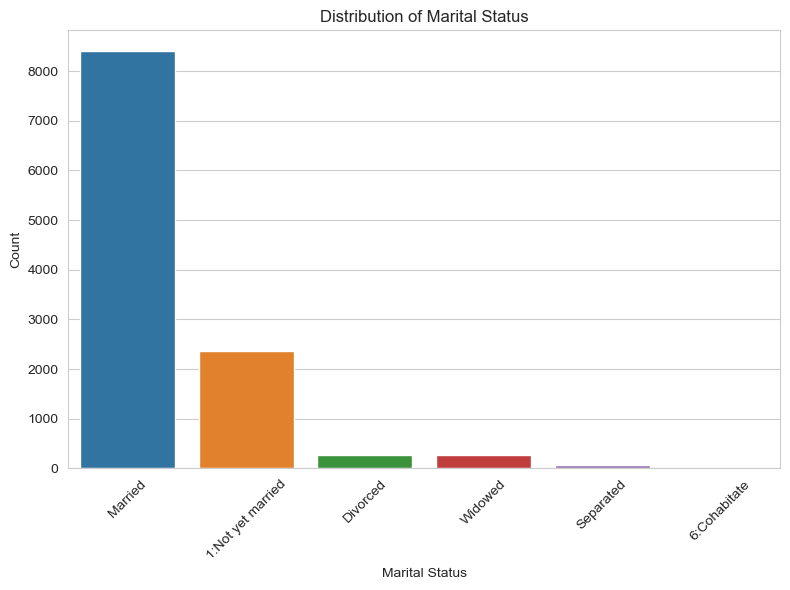

In [582]:
# 1. Marital Status (marstat) - Bar Chart
plt.figure(figsize=(8, 6))
sns.countplot(x='marstat', data=df_clean, order=df_clean['marstat'].value_counts().index)
plt.title('Distribution of Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('marital_status_distribution.png')
plt.show()

In [583]:
df_clean['age'].describe()

count   11385.000
mean       35.012
std        11.400
min        15.000
25%        26.000
50%        33.000
75%        42.000
max        84.000
Name: age, dtype: float64

In [585]:
df_clean['sex'].value_counts()

sex
Male      7102
Female    4283
Name: count, dtype: int64

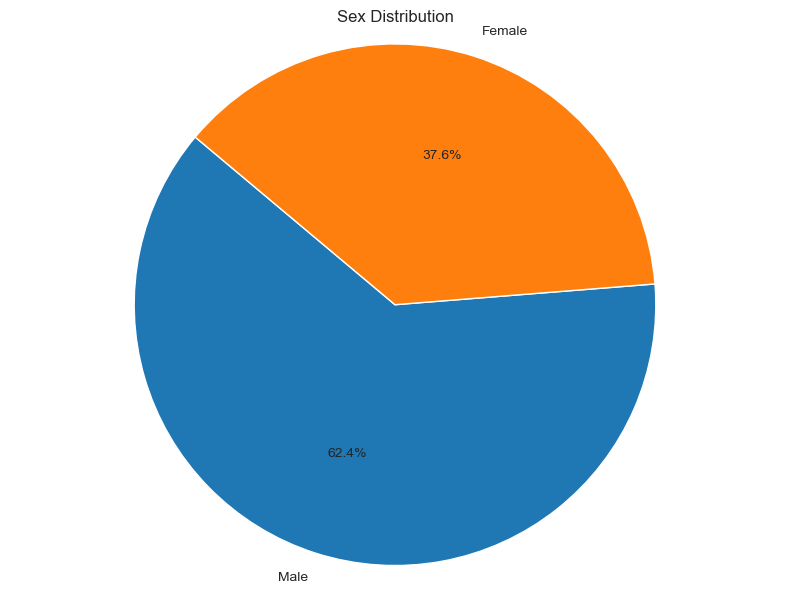

In [586]:
# 3. Sex - Pie Chart
plt.figure(figsize=(8, 6))
sex_counts = df_clean['sex'].value_counts()
plt.pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Sex Distribution')
plt.axis('equal')
plt.tight_layout()
plt.savefig('sex_distribution.png')
plt.show()

In [591]:
df_clean['ethnicity'].value_counts()

ethnicity
['Jawa']                                 5201
['Sunda']                                1508
['Minang']                                616
['Bali']                                  570
['Betawi']                                488
['Sasak']                                 470
['Batak']                                 395
['Bugis']                                 307
['Banjar']                                302
['Other South Sumatera']                  283
['Madura']                                258
['Makassar']                              185
['Bima-Dompu']                            180
['Melayu']                                 90
['Sumbawa']                                74
['Palembang']                              72
['Other']                                  65
['Tionghoa']                               54
['Toraja']                                 51
['Banten']                                 42
['Nias']                                   36
['Komering']            

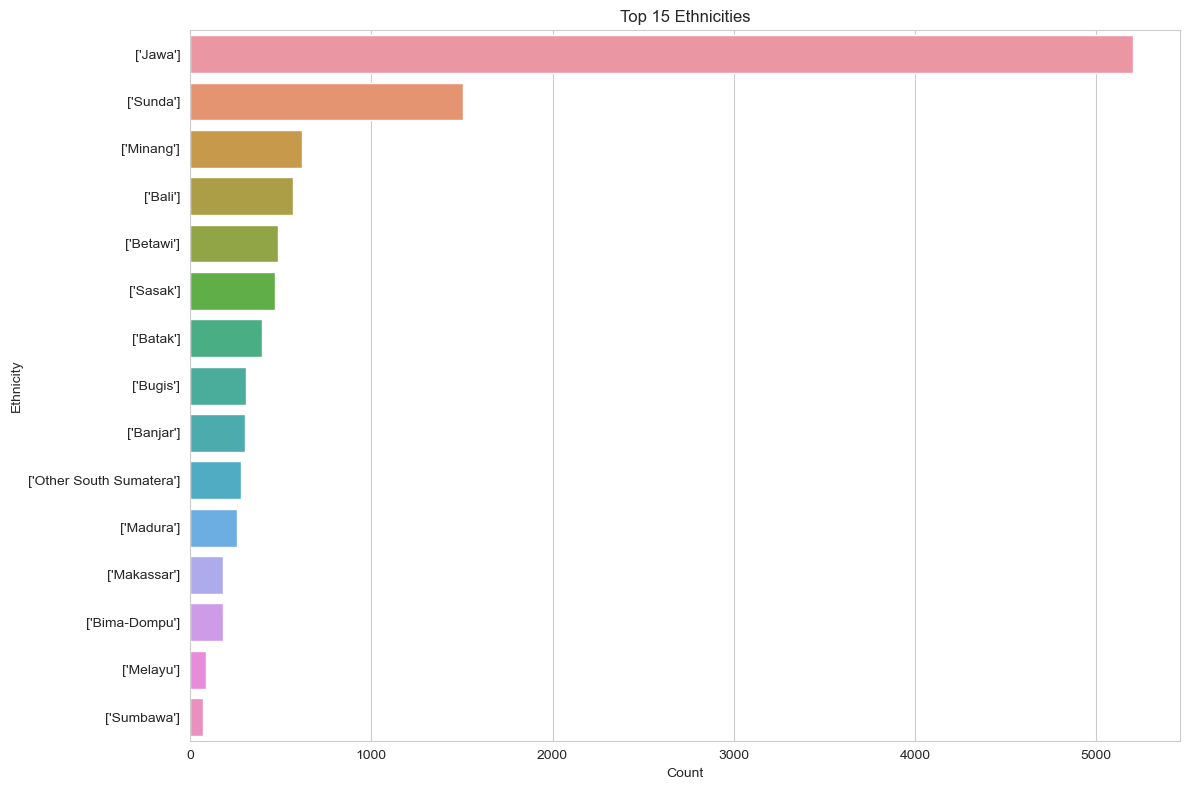

In [592]:
# 6. Ethnicity - Horizontal Bar Chart (Top 15)
plt.figure(figsize=(12, 8))
top_15_ethnicity = df_clean['ethnicity'].value_counts().nlargest(15)
sns.barplot(y=top_15_ethnicity.index, x=top_15_ethnicity.values, orient='h')
plt.title('Top 15 Ethnicities')
plt.xlabel('Count')
plt.ylabel('Ethnicity')
plt.tight_layout()
plt.savefig('ethnicity_distribution.png')
plt.show()

In [593]:
df_clean['education'].describe()

count   11385.000
mean       10.962
std         3.636
min         0.000
25%         9.000
50%        12.000
75%        13.000
max        22.000
Name: education, dtype: float64

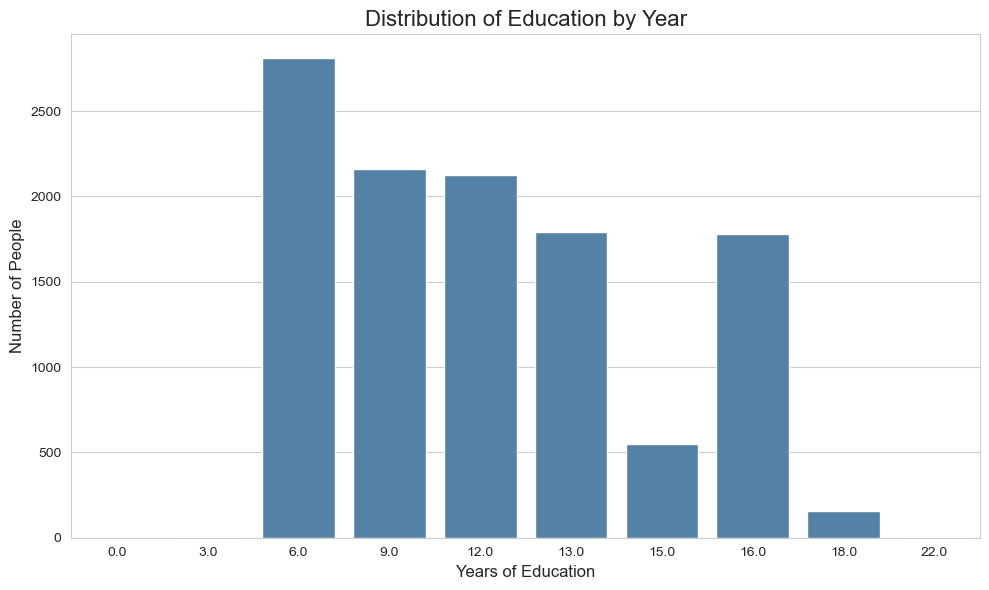

In [594]:
# 7. Education - Histogram
# Create a figure for the plot
plt.figure(figsize=(10, 6))

# Use countplot to create a bar for each unique year of education
sns.countplot(data=df_clean, x='education', color='steelblue')

# Set labels and title
plt.title('Distribution of Education by Year', fontsize=16)
plt.xlabel('Years of Education', fontsize=12)
plt.ylabel('Number of People', fontsize=12)

# Adjust layout and save the plot
plt.tight_layout()
plt.savefig('education_distribution_corrected.png')

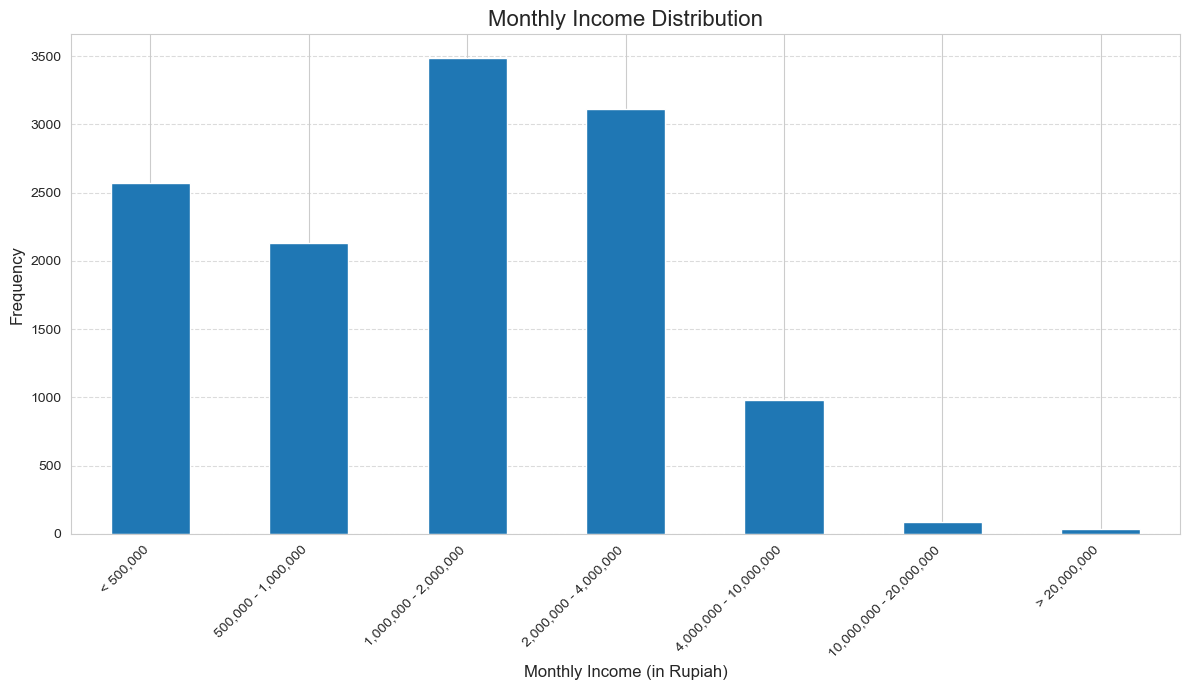

In [597]:
# Create a bar chart
plt.figure(figsize=(12, 7))
income_counts.plot(kind='bar')

# Set labels and title
plt.title('Monthly Income Distribution', fontsize=16)
plt.xlabel('Monthly Income (in Rupiah)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add a grid for easier reading
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout to make sure labels are not cut off
plt.tight_layout()

# Save the plot
plt.savefig('income_distribution_bar_chart.png')

### Process

In [598]:
df = pd.read_csv('clean_data/data_clean.csv')

# Variabel Dependen: is_divorced
df['is_divorced'] = df['marstat'].apply(lambda x: 1 if x in ['Divorced', 'Separated'] else 0)
df = df[df['marstat']!= 'Widowed']

# Variabel Independen
df['income_log'] = np.log1p(df['income/month'])
df['age'] = df['age'].astype(int)
df['age_squared'] = df['age']**2
df['education'] = df['education'].astype(float)

# Pemrosesan Variabel Etnis
def clean_ethnicity(eth_str):
    try:
        eth_list = ast.literal_eval(eth_str)
        return eth_list[0] if eth_list else 'Other'
    except (ValueError, SyntaxError):
        return 'Other'

df['ethnicity_clean'] = df['ethnicity'].apply(clean_ethnicity)
top_ethnicities = ['Jawa', 'Sunda', 'Sasak', 'Minang', 'Bali', 'Batak', 'Betawi', 'Bugis', 'Banjar']
df['ethnicity_grouped'] = df['ethnicity_clean'].apply(lambda x: x if x in top_ethnicities else 'Other')

# Membuat variabel dummy untuk etnis, dengan etnis pertama sebagai referensi
ethnicity_dummies = pd.get_dummies(df['ethnicity_grouped'], prefix='eth', drop_first=True)
df = pd.concat([df, ethnicity_dummies], axis=1)

# Membuat variabel dummy untuk cara perjodohan, dengan nilai pertama sebagai referensi
partner_choice_dummies = pd.get_dummies(df['who_chose_your_partner'], prefix='choice', drop_first=True)
df = pd.concat([df, partner_choice_dummies], axis=1)

# ----------------- KODE PERBAIKAN DIMULAI DARI SINI -----------------

# 1. Definisikan prediktor dasar (non-dummy)
base_predictors = ['age', 'age_squared', 'education', 'income_log']

# 2. Ambil nama kolom dari DataFrame dummy yang sudah dibuat
ethnicity_cols = ethnicity_dummies.columns.tolist()
partner_choice_cols = partner_choice_dummies.columns.tolist()

# 3. Gabungkan semua prediktor menjadi satu daftar final
predictor_cols_final = base_predictors + ethnicity_cols + partner_choice_cols

print("Variabel prediktor yang digunakan dalam model:")
print(predictor_cols_final)
print("\n")


# 4. Memisahkan Data Berdasarkan Jenis Kelamin
df_male = df[df['sex'] == 'Male'].copy()
df_female = df[df['sex'] == 'Female'].copy()

# Konversi semua kolom boolean di df_male menjadi integer (0 dan 1)
for col in df_male.select_dtypes(include='bool').columns:
    df_male[col] = df_male[col].astype(int)

# Lakukan hal yang sama untuk df_female
for col in df_female.select_dtypes(include='bool').columns:
    df_female[col] = df_female[col].astype(int)


# 5. Mendefinisikan dan Menjalankan Model Regresi Logistik (FUNGSI YANG DIPERBAIKI)
def run_logistic_regression(data, dependent_var, predictors):
    """Fungsi untuk menjalankan regresi logistik dan menampilkan hasilnya."""
    # Pastikan tidak ada nilai NaN di kolom yang relevan
    data = data.dropna(subset=[dependent_var] + predictors)
    
    X = data[predictors]
    y = data[dependent_var]
    
    X = sm.add_constant(X, has_constant='add')
    
    logit_model = sm.Logit(y, X)
    result = logit_model.fit(disp=0)
    
    # Menghitung Odds Ratio dan Confidence Intervalnya
    params = result.params
    conf = result.conf_int()
    conf['Odds Ratio'] = params
    conf.columns = ['Lower CI', 'Upper CI', 'Odds Ratio']
    conf = np.exp(conf)
    
    summary_df = pd.DataFrame({
        'Coefficient (B)': result.params,
        'Std.Err.': result.bse,
        'P-value': result.pvalues.map('{:.4f}'.format)
    })
    summary_df = summary_df.join(conf)
    
    print(f"Pseudo R-squ.: {result.prsquared:.4f}")
    print(f"N: {int(result.nobs)}")
    print(summary_df)
    print("\n" + "="*50 + "\n")

# Menjalankan model untuk Pria
print("Hasil Regresi Logistik untuk Pria")
run_logistic_regression(df_male, 'is_divorced', predictor_cols_final)

# Menjalankan model untuk Wanita
print("Hasil Regresi Logistik untuk Wanita")
run_logistic_regression(df_female, 'is_divorced', predictor_cols_final)

Variabel prediktor yang digunakan dalam model:
['age', 'age_squared', 'education', 'income_log', 'eth_Banjar', 'eth_Batak', 'eth_Betawi', 'eth_Bugis', 'eth_Jawa', 'eth_Minang', 'eth_Other', 'eth_Sasak', 'eth_Sunda', 'choice_Parents', 'choice_Self']


Hasil Regresi Logistik untuk Pria
Pseudo R-squ.: 0.0353
N: 2496
                Coefficient (B)  Std.Err. P-value  Lower CI  Upper CI  \
const                    -2.577     2.018  0.2017     0.001     3.971   
age                       0.056     0.081  0.4899     0.902     1.240   
age_squared              -0.000     0.001  0.6410     0.998     1.002   
education                -0.091     0.038  0.0160     0.848     0.983   
income_log               -0.033     0.037  0.3667     0.900     1.040   
eth_Banjar               -0.367     0.885  0.6785     0.122     3.929   
eth_Batak                -1.321     1.132  0.2430     0.029     2.453   
eth_Betawi               -0.006     0.726  0.9932     0.240     4.120   
eth_Bugis                -0.

### Process 2

In [599]:
df = pd.read_csv('clean_data/data_clean2.csv')
df

,pidlink,marstat,age,sex,ever_married,male,ethnicity,education,monthly_income,yearly_income,ethnicity_clean,ethnicity_grouped,is_divorced,log_income,sex_numeric,is_jawa,is_sunda,age_squared,survey_weight
0,1220003,Married,34.000,Male,1,1,['Nias'],16.000,0.000,3500000.000,Nias,Other,0,0.000,1,0,0,1156.000,1.089
1,1220006,1:Not yet married,28.000,Male,0,1,['Nias'],16.000,2000000.000,8000000.000,Nias,Other,0,14.509,1,0,0,784.000,1.089
2,1220008,1:Not yet married,24.000,Male,0,1,['Nias'],16.000,700000.000,2050000.000,Nias,Other,0,13.459,1,0,0,576.000,1.089
3,1240007,1:Not yet married,30.000,Female,0,0,['Nias'],16.000,200000.000,3600000.000,Nias,Other,0,12.206,0,0,0,900.000,1.089
4,1240016,1:Not yet married,17.000,Male,0,1,['Nias'],13.000,240000.000,240000.000,Nias,Other,0,12.388,1,0,0,289.000,1.089
5,1240024,1:Not yet married,25.000,Female,0,0,['Batak'],16.000,1700000.000,6800000.000,Batak,Other,0,14.346,0,0,0,625.000,1.089
6,1245201,Married,30.000,Male,1,1,['Nias'],9.000,800000.000,1200000.000,Nias,Other,0,13.592,1,0,0,900.000,1.089
7,1290004,Married,29.000,Male,1,1,['Nias'],6.000,400000.000,3000000.000,Nias,Other,0,12.899,1,0,0,841.000,1.089
8,2010005,1:Not yet married,26.000,Male,0,1,['Nias'],15.000,1400000.000,17300000.000,Nias,Other,0,14.152,1,0,0,676.000,1.089
9,2010006,Married,24.000,Female,1,0,['Nias'],6.000,1500000.000,4700000.000,Nias,Other,0,14.221,0,0,0,576.000,1.089


In [600]:
df['sex'].value_counts()

sex
Male      7102
Female    4283
Name: count, dtype: int64

In [601]:
df['ethnicity'].value_counts()

ethnicity
['Jawa']                                 5201
['Sunda']                                1508
['Minang']                                616
['Bali']                                  570
['Betawi']                                488
['Sasak']                                 470
['Batak']                                 395
['Bugis']                                 307
['Banjar']                                302
['Other South Sumatera']                  283
['Madura']                                258
['Makassar']                              185
['Bima-Dompu']                            180
['Melayu']                                 90
['Sumbawa']                                74
['Palembang']                              72
['Other']                                  65
['Tionghoa']                               54
['Toraja']                                 51
['Banten']                                 42
['Nias']                                   36
['Komering']            

# fix

In [603]:
# 1. Ever married (you already have this)
df_clean['ever_married'] = (df_clean['marstat'] != '1:Not yet married').astype(int)

# 2. Ever divorced (only among ever married)
df_clean['is_divorced'] = df_clean['marstat'].isin(['4:Divorced', '3:Separated']).astype(int)

# 3. Remarried (married more than once — currently married but was previously divorced)
# In IFLS this needs marriage history — approximate with currently married among ever divorced
df_ever_married = df_clean[df_clean['ever_married'] == 1].copy()
df_ever_divorced = df_clean[df_clean['is_divorced'] == 1].copy()

print("Ever married   :", df_clean['ever_married'].sum())
print("Ever divorced  :", df_clean['is_divorced'].sum())
print(df_clean['marstat'].value_counts())

Ever married   : 9011
Ever divorced  : 0
marstat
Married              8400
1:Not yet married    2374
Divorced              275
Widowed               267
Separated              66
6:Cohabitate            3
Name: count, dtype: int64


In [623]:
# See ALL column names exactly
print(df_clean.columns.tolist())

['pidlink', 'marstat', 'age', 'sex', 'ever_married', 'male', 'ethnicity', 'education', 'monthly_income', 'yearly_income', 'ethnicity_clean', 'ethnicity_grouped', 'is_divorced', 'log_income', 'sex_numeric', 'is_jawa', 'is_sunda', 'age_squared', 'survey_weight']


In [624]:
# Already exists — just verify
print(df_clean[['monthly_income', 'yearly_income', 'log_income', 'age_squared']].describe())

print("\nOutcomes:")
print("ever_married :", df_clean['ever_married'].value_counts().to_dict())
print("is_divorced  :", df_clean['is_divorced'].value_counts().to_dict())

print("\nSex split:")
print("Male   :", len(df_clean[df_clean['sex'] == '1:Male']))
print("Female :", len(df_clean[df_clean['sex'] == '3:Female']))

       monthly_income  yearly_income  log_income  age_squared
count       11383.000      11383.000   11383.000    11385.000
mean      1751654.748   20453061.142      13.316     1355.788
std       2237573.835   30001318.270       3.130      892.709
min             0.000          0.000       0.000      225.000
25%        571000.000    4000000.000      13.255      676.000
50%       1250000.000   12000000.000      14.039     1089.000
75%       2400000.000   26975000.000      14.691     1764.000
max      90000000.000  910000000.000      18.315     7056.000

Outcomes:
ever_married : {1: 9011, 0: 2374}
is_divorced  : {0: 11385}

Sex split:
Male   : 0
Female : 0


In [625]:
# 999999997 and 999999999 are IFLS codes for missing/unknown
# Replace them with NaN

IFLS_MISSING = [999999997, 999999998, 999999999]

df_clean['monthly_income'] = df_clean['monthly_income'].replace(IFLS_MISSING, np.nan)
df_clean['yearly_income']  = df_clean['yearly_income'].replace(IFLS_MISSING, np.nan)

# Recreate log_income after cleaning
df_clean['log_income'] = np.log1p(df_clean['monthly_income'])

# Verify — max should now be realistic
print(df_clean[['monthly_income', 'yearly_income', 'log_income']].describe())

print("\nMissing after cleaning:")
print("monthly_income NaN:", df_clean['monthly_income'].isna().sum())
print("yearly_income NaN :", df_clean['yearly_income'].isna().sum())

       monthly_income  yearly_income  log_income
count       11383.000      11383.000   11383.000
mean      1751654.748   20453061.142      13.316
std       2237573.835   30001318.270       3.130
min             0.000          0.000       0.000
25%        571000.000    4000000.000      13.255
50%       1250000.000   12000000.000      14.039
75%       2400000.000   26975000.000      14.691
max      90000000.000  910000000.000      18.315

Missing after cleaning:
monthly_income NaN: 2
yearly_income NaN : 2


In [626]:
print("\nOutcomes:")
print("ever_married :", df_clean['ever_married'].value_counts().to_dict())
print("is_divorced  :", df_clean['is_divorced'].value_counts().to_dict())


Outcomes:
ever_married : {1: 9011, 0: 2374}
is_divorced  : {0: 11385}


### Check how many NaN exist per var

In [627]:
# Check how many NaN exist per variable
cols = ['log_income', 'education', 'age', 'age_squared', 'is_jawa', 'is_sunda', 
        'ever_married', 'is_divorced']

print("=== NaN counts in df_female ===")
print(df_female[cols].isna().sum())

print("\n=== NaN counts in df_male ===")
print(df_male[cols].isna().sum())

print("\n=== Rows remaining after dropna ===")
print("Female:", len(df_female.dropna(subset=cols)))
print("Male  :", len(df_male.dropna(subset=cols)))

=== NaN counts in df_female ===
log_income      1
education       0
age             0
age_squared     0
is_jawa         0
is_sunda        0
ever_married    0
is_divorced     0
dtype: int64

=== NaN counts in df_male ===
log_income      1
education       0
age             0
age_squared     0
is_jawa         0
is_sunda        0
ever_married    0
is_divorced     0
dtype: int64

=== Rows remaining after dropna ===
Female: 4282
Male  : 7101


In [628]:
# Check exact sex values in df_clean
print(df_clean['sex'].value_counts())
print(df_clean['sex'].dtype)

sex
Male      7102
Female    4283
Name: count, dtype: int64
object


## Ever Married

In [629]:
# Correct filter
df_male   = df_clean[df_clean['sex'] == 'Male'].copy()
df_female = df_clean[df_clean['sex'] == 'Female'].copy()

print("Male  :", len(df_male))
print("Female:", len(df_female))

# Now run the models
cols = ['log_income', 'education', 'age', 'age_squared', 
        'is_jawa', 'is_sunda', 'ever_married', 'is_divorced']

formula_base = "~ log_income + education + age + age_squared + is_jawa + is_sunda"

# ── Model 1: Ever Married ──────────────────────────────────────────
print("\n>>> MODEL 1: EVER MARRIED <<<")
m1_female = run_model(df_female, 'ever_married', formula_base, 'Ever Married - Women')
m1_male   = run_model(df_male,   'ever_married', formula_base, 'Ever Married - Men')

# ── Model 2: Ever Divorced (among ever married only) ───────────────
print("\n>>> MODEL 2: EVER DIVORCED <<<")
df_em_female = df_female[df_female['ever_married'] == 1].copy()
df_em_male   = df_male[df_male['ever_married'] == 1].copy()
m2_female = run_model(df_em_female, 'is_divorced', formula_base, 'Ever Divorced - Women')
m2_male   = run_model(df_em_male,   'is_divorced', formula_base, 'Ever Divorced - Men')

Male  : 7102
Female: 4283

>>> MODEL 1: EVER MARRIED <<<

Model: Ever Married - Women | N=4282
Pseudo R²: 0.454
             Coef.  Std.Err.  P>|z|
Intercept   -9.560     0.515  0.000
log_income  -0.057     0.017  0.001
education   -0.202     0.018  0.000
age          0.729     0.031  0.000
age_squared -0.008     0.000  0.000
is_jawa      0.216     0.114  0.057
is_sunda     0.603     0.186  0.001

Model: Ever Married - Men | N=7101
Pseudo R²: 0.438
              Coef.  Std.Err.  P>|z|
Intercept   -11.057     0.418  0.000
log_income    0.049     0.013  0.000
education    -0.076     0.013  0.000
age           0.595     0.022  0.000
age_squared  -0.006     0.000  0.000
is_jawa       0.042     0.085  0.617
is_sunda      0.056     0.125  0.654

>>> MODEL 2: EVER DIVORCED <<<

Model: Ever Divorced - Women | N=3462
Pseudo R²: inf
              Coef.   Std.Err.  P>|z|
Intercept   -15.076 825004.070  1.000
log_income   -0.334  21509.771  1.000
education    -0.199  41730.007  1.000
age          

c:\Users\hp\anaconda3\envs\myenv\lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\hp\anaconda3\envs\myenv\lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\hp\anaconda3\envs\myenv\lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\hp\anaconda3\envs\myenv\lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationW

## Ever Divorced

In [630]:
print(df_clean)

         pidlink            marstat    age     sex  ever_married  male  \
0        1220003            Married 34.000    Male             1     1   
1        1220006  1:Not yet married 28.000    Male             0     1   
2        1220008  1:Not yet married 24.000    Male             0     1   
3        1240007  1:Not yet married 30.000  Female             0     0   
4        1240016  1:Not yet married 17.000    Male             0     1   
5        1240024  1:Not yet married 25.000  Female             0     0   
6        1245201            Married 30.000    Male             1     1   
7        1290004            Married 29.000    Male             1     1   
8        2010005  1:Not yet married 26.000    Male             0     1   
9        2010006            Married 24.000  Female             1     0   
10       2010008  1:Not yet married 19.000  Female             0     0   
11       2020011            Married 22.000  Female             1     0   
12       2040006  1:Not yet married 20

In [632]:
# Check what marstat values exist in ever married subsample
print(df_clean_ever_married['marstat'].value_counts())

marstat
Married         8400
Divorced         275
Widowed          267
Separated         66
6:Cohabitate       3
Name: count, dtype: int64


In [633]:
# Recreate is_divorced with correct labels
df_clean['is_divorced'] = df_clean['marstat'].isin(['Divorced', 'Separated']).astype(int)

# Verify
print("Divorced in full data:")
print(df_clean['is_divorced'].value_counts())

# Recreate ever married subsample
df_clean_ever_married = df_clean[df_clean['ever_married'] == 1].copy()

# Re-split by sex
df_em_male   = df_clean_ever_married[df_clean_ever_married['sex'] == 'Male'].copy()
df_em_female = df_clean_ever_married[df_clean_ever_married['sex'] == 'Female'].copy()

print("\nAfter fix:")
print("Ever married total :", len(df_clean_ever_married))
print("Ever married male  :", len(df_em_male))
print("Ever married female:", len(df_em_female))
print("\nDivorced women:", df_em_female['is_divorced'].sum())
print("Divorced men  :", df_em_male['is_divorced'].sum())

Divorced in full data:
is_divorced
0    11044
1      341
Name: count, dtype: int64

After fix:
Ever married total : 9011
Ever married male  : 5548
Ever married female: 3463

Divorced women: 200
Divorced men  : 141


### Run Model

In [634]:
formula_divorce = "~ log_income + education + age + age_squared + is_jawa + is_sunda"

print("\n>>> MODEL 2: EVER DIVORCED (Ever Married Only) <<<")
m2_female = run_model(df_em_female, 'is_divorced', formula_divorce, 'Ever Divorced - Women')
m2_male   = run_model(df_em_male,   'is_divorced', formula_divorce, 'Ever Divorced - Men')

# Format results table
format_results_table(m2_female, m2_male, 'EVER DIVORCED (Ever Married Only)')


>>> MODEL 2: EVER DIVORCED (Ever Married Only) <<<



Model: Ever Divorced - Women | N=3462
Pseudo R²: 0.011
             Coef.  Std.Err.  P>|z|
Intercept   -2.679     0.883  0.002
log_income   0.058     0.030  0.052
education   -0.062     0.020  0.002
age         -0.008     0.041  0.855
age_squared  0.000     0.000  0.748
is_jawa     -0.323     0.158  0.040
is_sunda    -0.242     0.231  0.296

Model: Ever Divorced - Men | N=5547
Pseudo R²: 0.019
             Coef.  Std.Err.  P>|z|
Intercept   -2.569     1.034  0.013
log_income  -0.041     0.024  0.080
education   -0.072     0.026  0.005
age         -0.005     0.048  0.921
age_squared -0.000     0.001  0.988
is_jawa      0.586     0.203  0.004
is_sunda     0.671     0.261  0.010

TABLE: EVER DIVORCED (Ever Married Only)
Variable                    Women                   Men              Diff
                                Coef.(SE)            Coef.(SE)
------------------------------------------------------------
Intercept              -2.679**  (0.883)     -2.569*   (1.034)     -0.110


## Data Check

In [635]:
# Check age distribution in your ever married sample
print(df_clean_ever_married['age'].describe())

# Check divorce rate by age group
df_clean_ever_married['age_group'] = pd.cut(df_clean_ever_married['age'], 
                                             bins=[0,25,35,45,55,100],
                                             labels=['<25','25-35','35-45','45-55','55+'])

print(df_clean_ever_married.groupby('age_group')['is_divorced'].mean() * 100)

count   9011.000
mean      38.027
std       10.466
min       16.000
25%       30.000
50%       36.000
75%       45.000
max       84.000
Name: age, dtype: float64
age_group
<25     5.006
25-35   3.147
35-45   3.943
45-55   4.128
55+     4.035
Name: is_divorced, dtype: float64


C:\Users\hp\AppData\Local\Temp\ipykernel_29388\451303140.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_clean_ever_married.groupby('age_group')['is_divorced'].mean() * 100)


# End